### Environment Setup

In [1]:
# Local environment setup
from pathlib import Path

Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import gradio as gr

# Safe device detection (CPU / GPU compatibility)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU available:", gpus)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
else:
    print("GPU not available. Using CPU.")

print("Libraries imported successfully!")

GPU not available. Using CPU.
Libraries imported successfully!


Load Dataset

In [3]:
from pathlib import Path

DATASET_DIR = Path("dataset")
if not DATASET_DIR.exists() and (Path("INDIAN_DATASET") / "dataset").exists():
    DATASET_DIR = Path("INDIAN_DATASET") / "dataset"

file_path = DATASET_DIR / "hourlyLoadDataIndia.xlsx"

df = pd.read_excel(file_path)

df

,datetime,National Hourly Demand,Northen Region Hourly Demand,Western Region Hourly Demand,Eastern Region Hourly Demand,Southern Region Hourly Demand,North-Eastern Region Hourly Demand
0,2019-01-01 00:00:00,118690.67,33692.02,38522.22,13128.89,31681.83,1665.72
1,2019-01-01 01:00:00,116029.23,32534.39,38071.09,12737.53,31129.97,1556.24
2,2019-01-01 02:00:00,114044.14,31730.37,37680.10,12387.36,30760.87,1485.44
3,2019-01-01 03:00:00,113648.97,31529.25,37747.37,12301.12,30616.27,1454.96
4,2019-01-01 04:00:00,116290.05,32406.61,38101.80,12479.13,31839.38,1463.14
...,...,...,...,...,...,...,...
46723,2024-04-30 19:00:00,201094.24,56178.67,63314.47,26449.43,52398.59,2753.07
46724,2024-04-30 20:00:00,196577.71,55006.84,61164.46,26135.97,51599.69,2670.76
46725,2024-04-30 21:00:00,194782.12,52788.73,60500.94,26026.27,52945.71,2520.46
46726,2024-04-30 22:00:00,194967.39,50979.46,61707.05,25467.19,54495.57,2318.11


Clean the dataset

In [4]:
df['datetime'] = pd.to_datetime(
    df['datetime'],
    errors='coerce'
)

df = df.dropna(subset=['datetime'])

df = df.sort_values('datetime')

df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape after cleaning: (46728, 7)

Missing values:
datetime                              0
National Hourly Demand                0
Northen Region Hourly Demand          0
Western Region Hourly Demand          0
Eastern Region Hourly Demand          0
Southern Region Hourly Demand         0
North-Eastern Region Hourly Demand    0
dtype: int64


Select National Demand

In [5]:
target = 'National Hourly Demand'

data = df[['datetime', target]].copy()

data = data.dropna()

print("Target:", target)
print("Unit: MW")

display(data.head())

Target: National Hourly Demand
Unit: MW


,datetime,National Hourly Demand
0,2019-01-01 00:00:00,118690.67
1,2019-01-01 01:00:00,116029.23
2,2019-01-01 02:00:00,114044.14
3,2019-01-01 03:00:00,113648.97
4,2019-01-01 04:00:00,116290.05


Plot electricity demand

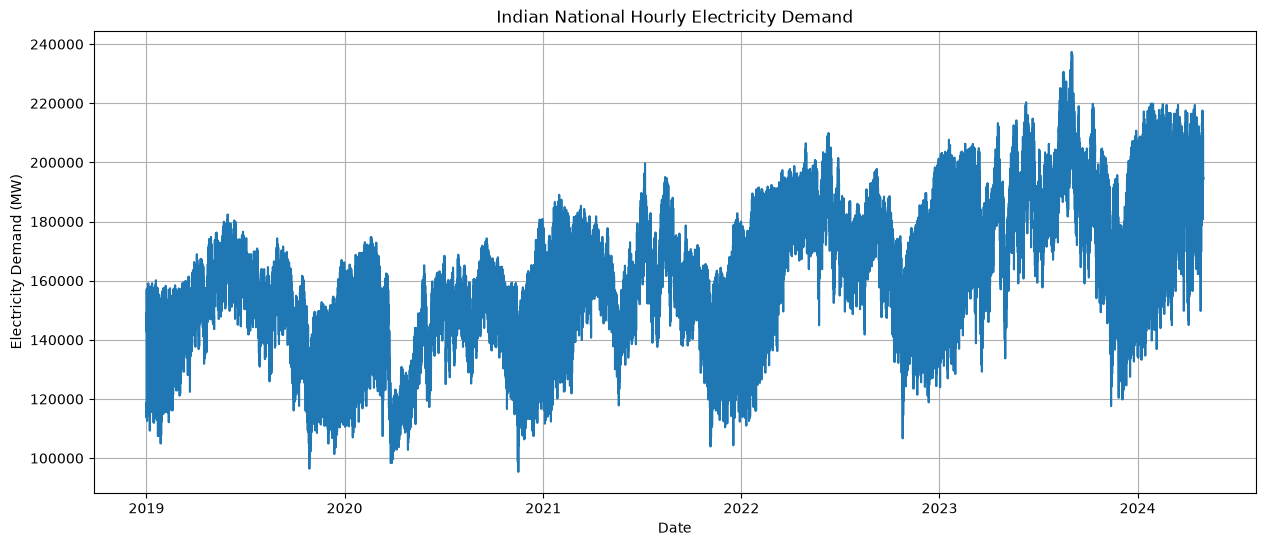

In [6]:
plt.figure(figsize=(15, 6))

plt.plot(
    data['datetime'],
    data[target]
)

plt.title(
    'Indian National Hourly Electricity Demand'
)

plt.xlabel('Date')
plt.ylabel('Electricity Demand (MW)')

plt.grid(True)

plt.show()

Train Test Split

In [7]:
split_index = int(len(data) * 0.80)

train_data = data.iloc[:split_index].copy()
test_data = data.iloc[split_index:].copy()

print("Training records:", len(train_data))
print("Testing records:", len(test_data))

Training records: 37382
Testing records: 9346


Scaling

In [8]:
scaler = MinMaxScaler(
    feature_range=(0, 1)
)

train_values = train_data[[target]].values

test_values = test_data[[target]].values

train_scaled = scaler.fit_transform(train_values)

test_scaled = scaler.transform(test_values)

print("Training scaled shape:", train_scaled.shape)
print("Testing scaled shape:", test_scaled.shape)

Training scaled shape: (37382, 1)
Testing scaled shape: (9346, 1)


Create sequences

In [9]:
TIME_STEPS = 24

def create_sequences(values, time_steps):

    X = []
    y = []

    for i in range(time_steps, len(values)):

        X.append(
            values[i-time_steps:i, 0]
        )

        y.append(
            values[i, 0]
        )

    return np.array(X), np.array(y)

Create training sequences

In [10]:
X_train, y_train = create_sequences(
    train_scaled,
    TIME_STEPS
)

print("X_train shape before reshape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape before reshape: (37358, 24)
y_train shape: (37358,)


In [11]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

print("X_train shape:", X_train.shape)

X_train shape: (37358, 24, 1)


Create testing sequences

In [12]:
combined_values = np.concatenate(
    [train_scaled[-TIME_STEPS:], test_scaled]
)

X_test, y_test_scaled = create_sequences(
    combined_values,
    TIME_STEPS
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test_scaled.shape)

X_test shape: (9346, 24, 1)
y_test shape: (9346,)


Building LSTM model

In [13]:
model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(TIME_STEPS, 1)
    ),

    Dropout(0.2),

    LSTM(
        32,
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Train LSTM

In [14]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [15]:
history = model.fit(

    X_train,
    y_train,

    epochs=30,

    batch_size=64,

    validation_split=0.1,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/30
526/526 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - loss: 0.0136 - val_loss: 0.0053
Epoch 2/30
526/526 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0038 - val_loss: 0.0018
Epoch 3/30
526/526 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 4/30
526/526 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 5/30
526/526 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0014 - val_loss: 8.4193e-04
Epoch 6/30
526/526 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0012 - val_loss: 7.4991e-04
Epoch 7/30
526/526 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0011 - val_loss: 6.0845e-04
Epoch 8/30
526/526 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 9.5232e-04 - val_loss: 5.5950e-04
Epoch 9/30
526/526 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 9.0482e-04 - val_loss: 5.7748e-04
Epoch 10/30
526/526 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 8.7132e-04 - val_loss: 5.7961e-04
Epoch 11/30
526/526 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 8.4336e-04 - val_loss: 5

Plot training loss

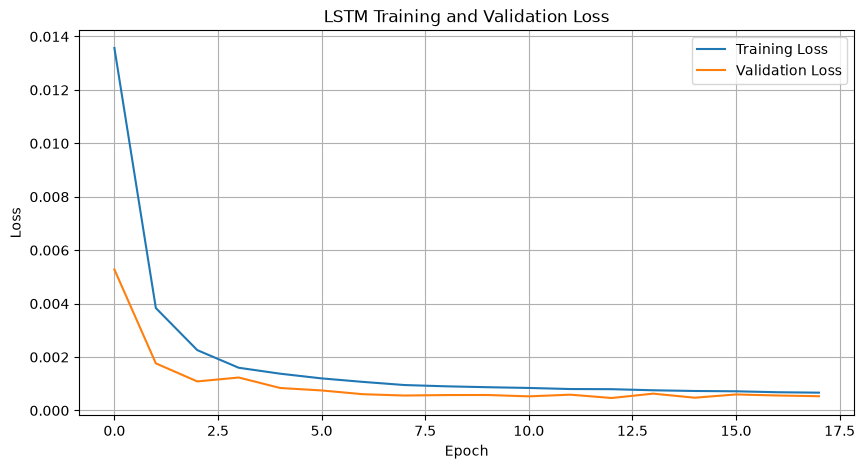

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Training and Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.show()

Make predictions

In [17]:
y_pred_scaled = model.predict(
    X_test,
    verbose=1
)

print("Prediction shape:", y_pred_scaled.shape)

293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Prediction shape: (9346, 1)


Convert predictions back to MW

In [18]:
y_pred = scaler.inverse_transform(
    y_pred_scaled
)

y_test = scaler.inverse_transform(
    y_test_scaled.reshape(-1, 1)
)

print("First 10 actual values:")
print(y_test[:10].flatten())

print("\nFirst 10 predicted values:")
print(y_pred[:10].flatten())

First 10 actual values:
[183298.8  183642.74 180148.32 173698.41 174092.89 182541.83 178704.1
 175628.75 175838.78 174420.57]

First 10 predicted values:
[180214.06 183142.17 180686.88 178391.11 172853.47 177170.56 183788.89
 175229.19 176358.47 174118.88]


Evaluate LSTM

In [19]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("LSTM PERFORMANCE")
print("============================")
print(f"MAE  : {mae:.2f} MW")
print(f"MSE  : {mse:.2f} MW²")
print(f"RMSE : {rmse:.2f} MW")
print(f"R²   : {r2:.4f}")

LSTM PERFORMANCE
MAE  : 2245.32 MW
MSE  : 8434034.17 MW²
RMSE : 2904.14 MW
R²   : 0.9779


Plot actual vs predicted

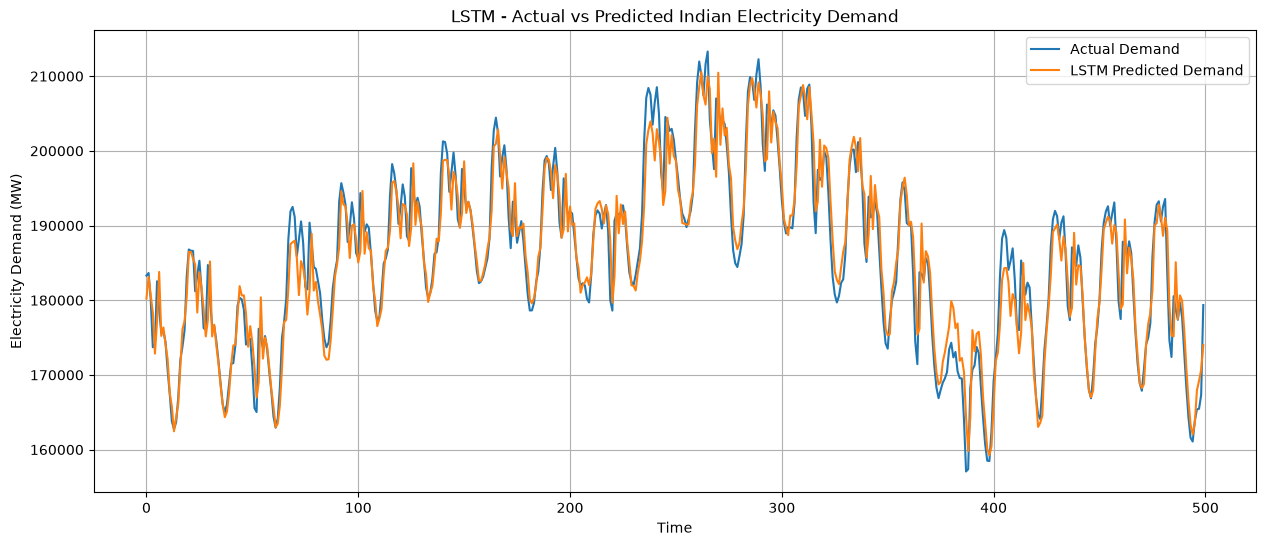

In [20]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test[:500],
    label='Actual Demand'
)

plt.plot(
    y_pred[:500],
    label='LSTM Predicted Demand'
)

plt.title(
    'LSTM - Actual vs Predicted Indian Electricity Demand'
)

plt.xlabel('Time')

plt.ylabel('Electricity Demand (MW)')

plt.legend()

plt.grid(True)

plt.show()

Prediction function

In [21]:
def predict_lstm(date, time):

    try:

        requested_datetime = pd.to_datetime(
            f"{date} {time}"
        )

        # Find the nearest available timestamp
        time_differences = abs(
            data['datetime'] - requested_datetime
        )

        nearest_index = time_differences.idxmin()

        position = data.index.get_loc(
            nearest_index
        )

        if position < TIME_STEPS:

            return (
                "Not enough previous data for this time. "
                "Please select a later date."
            )

        # Get previous 24 hours
        previous_values = data.iloc[
            position - TIME_STEPS:position
        ][target].values.reshape(-1, 1)

        # Scale
        previous_scaled = scaler.transform(
            previous_values
        )

        # Reshape for LSTM
        sequence = previous_scaled.reshape(
            1,
            TIME_STEPS,
            1
        )

        # Predict
        prediction_scaled = model.predict(
            sequence,
            verbose=0
        )

        # Convert back to MW
        prediction = scaler.inverse_transform(
            prediction_scaled
        )[0][0]

        actual_value = data.iloc[position][target]

        actual_datetime = data.iloc[position]['datetime']

        return (
            f"Predicted National Electricity Demand: "
            f"{prediction:,.2f} MW\n\n"
            f"Dataset timestamp used: "
            f"{actual_datetime}\n\n"
            f"Actual recorded demand: "
            f"{actual_value:,.2f} MW"
        )

    except Exception as e:

        return f"Error: {str(e)}"

In [22]:
result = predict_lstm(
    "2024-04-01",
    "18:00"
)

print(result)

Predicted National Electricity Demand: 186,648.89 MW

Dataset timestamp used: 2024-04-01 18:00:00

Actual recorded demand: 185,414.67 MW


UI

In [23]:
# ==============================================================================
# Dark Glassmorphism Gradio Interface: Indian Electricity Load Forecasting
# ==============================================================================
import gradio as gr
import pandas as pd

# Preserve original prediction function and add friendly validation error handling
_orig_predict_predict_lstm = predict_lstm

def predict_lstm(date, time):
    if not date or not str(date).strip() or not time or not str(time).strip():
        return "⚠️ Please enter a valid date and time."
    try:
        pd.to_datetime(f"{date} {time}")
    except Exception:
        return "⚠️ Please enter a valid date (YYYY-MM-DD) and time (24-hour format: HH:00)."
    res = _orig_predict_predict_lstm(date, time)
    if isinstance(res, str):
        if "Not enough previous data" in res:
            return "⚠️ Not enough historical data is available for this prediction."
        if res.startswith("Error:"):
            return "⚠️ Please enter a valid date and time within the dataset range."
    return res

CUSTOM_CSS = """
/* ==============================================================================
   DARK GLASSMORPHISM CYBER-GRID THEME (PBL AI DASHBOARD)
   ============================================================================== */

.gradio-container {
    max-width: 1040px !important;
    margin: 0 auto !important;
    background: radial-gradient(circle at top left, #0f172a 0%, #030712 100%) !important;
    color: #f1f5f9 !important;
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, "Helvetica Neue", sans-serif !important;
    min-height: 100vh !important;
}

@keyframes fadeInScale {
    0% { opacity: 0; transform: translateY(10px) scale(0.99); }
    100% { opacity: 1; transform: translateY(0) scale(1); }
}

/* Glassmorphism Header */
.sg-header-glass {
    background: rgba(15, 23, 42, 0.75) !important;
    backdrop-filter: blur(20px) !important;
    -webkit-backdrop-filter: blur(20px) !important;
    border: 1px solid rgba(255, 255, 255, 0.08) !important;
    border-top: 1px solid rgba(56, 189, 248, 0.4) !important;
    border-radius: 22px !important;
    padding: 28px 32px 24px !important;
    margin-bottom: 22px !important;
    text-align: center !important;
    box-shadow: 0 16px 36px -10px rgba(0, 0, 0, 0.6) !important;
    animation: fadeInScale 0.6s cubic-bezier(0.16, 1, 0.3, 1) !important;
    position: relative !important;
    overflow: hidden !important;
    transition: all 0.3s ease !important;
}

.sg-header-glass:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 20px 40px -10px rgba(0, 0, 0, 0.75), 0 0 25px rgba(56, 189, 248, 0.15) !important;
}

.sg-header-glass::before {
    content: '' !important;
    position: absolute !important;
    top: 0 !important;
    left: 20% !important;
    right: 20% !important;
    height: 1px !important;
    background: linear-gradient(90deg, transparent, #38bdf8, #818cf8, transparent) !important;
}

.sg-badge-glass {
    display: inline-flex !important;
    align-items: center !important;
    gap: 8px !important;
    background: rgba(30, 41, 59, 0.8) !important;
    border: 1px solid rgba(56, 189, 248, 0.3) !important;
    color: #38bdf8 !important;
    font-size: 11px !important;
    font-weight: 700 !important;
    text-transform: uppercase !important;
    letter-spacing: 0.1em !important;
    padding: 5px 16px !important;
    border-radius: 9999px !important;
    margin-bottom: 12px !important;
    box-shadow: 0 0 15px rgba(56, 189, 248, 0.15) !important;
}

.sg-title-glass {
    font-size: 28px !important;
    font-weight: 800 !important;
    color: #ffffff !important;
    letter-spacing: -0.02em !important;
    margin: 0 0 4px 0 !important;
    text-shadow: 0 2px 10px rgba(0, 0, 0, 0.5) !important;
}

.sg-title-sub-glass {
    font-size: 16px !important;
    font-weight: 600 !important;
    color: #38bdf8 !important;
    margin: 0 0 10px 0 !important;
    letter-spacing: -0.01em !important;
}

.sg-model-tag-glass {
    display: inline-block !important;
    background: rgba(14, 165, 233, 0.12) !important;
    color: #7dd3fc !important;
    font-size: 13px !important;
    font-weight: 700 !important;
    padding: 5px 16px !important;
    border-radius: 10px !important;
    border: 1px solid rgba(56, 189, 248, 0.25) !important;
    margin-bottom: 8px !important;
}

.sg-subtitle-glass {
    font-size: 13px !important;
    color: #94a3b8 !important;
    margin: 0 !important;
}

/* Glass Cards */
.sg-card-glass {
    background: rgba(15, 23, 42, 0.65) !important;
    backdrop-filter: blur(16px) !important;
    -webkit-backdrop-filter: blur(16px) !important;
    border: 1px solid rgba(255, 255, 255, 0.08) !important;
    border-radius: 18px !important;
    padding: 18px 20px !important;
    margin-bottom: 16px !important;
    box-shadow: 0 10px 25px -5px rgba(0, 0, 0, 0.4) !important;
    transition: all 0.3s cubic-bezier(0.16, 1, 0.3, 1) !important;
    animation: fadeInScale 0.7s cubic-bezier(0.16, 1, 0.3, 1) !important;
}

.sg-card-glass:hover {
    transform: translateY(-2px) !important;
    border-color: rgba(56, 189, 248, 0.3) !important;
    box-shadow: 0 14px 32px -4px rgba(0, 0, 0, 0.6), 0 0 20px rgba(56, 189, 248, 0.1) !important;
}

.sg-card-header-glass {
    font-size: 14px !important;
    font-weight: 700 !important;
    color: #f8fafc !important;
    margin-bottom: 12px !important;
    display: flex !important;
    align-items: center !important;
    gap: 8px !important;
    text-transform: uppercase !important;
    letter-spacing: 0.05em !important;
}

/* Futuristic Glowing Button */
.sg-btn-glow {
    background: linear-gradient(135deg, #0284c7 0%, #2563eb 50%, #4f46e5 100%) !important;
    color: #ffffff !important;
    font-weight: 700 !important;
    font-size: 15px !important;
    border: 1px solid rgba(255, 255, 255, 0.2) !important;
    border-radius: 14px !important;
    padding: 13px 26px !important;
    box-shadow: 0 0 20px rgba(14, 165, 233, 0.35), 0 4px 12px rgba(0, 0, 0, 0.5) !important;
    cursor: pointer !important;
    transition: all 0.25s ease !important;
    width: 100% !important;
}

.sg-btn-glow:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 0 30px rgba(14, 165, 233, 0.6), 0 8px 24px rgba(0, 0, 0, 0.6) !important;
    filter: brightness(1.1) !important;
}

.sg-btn-glow:active {
    transform: translateY(0) !important;
}

/* Dark Component Overrides */
.gradio-container input,
.gradio-container textarea,
.gradio-container .block,
.gradio-container .input-container {
    background: rgba(15, 23, 42, 0.75) !important;
    color: #f8fafc !important;
    border-color: rgba(255, 255, 255, 0.1) !important;
    border-radius: 12px !important;
}

.gradio-container input:focus,
.gradio-container textarea:focus {
    border-color: #38bdf8 !important;
    box-shadow: 0 0 12px rgba(56, 189, 248, 0.3) !important;
}

.gradio-container label span {
    color: #94a3b8 !important;
    font-weight: 600 !important;
}

/* Info Grid & Meta Rows */
.sg-info-grid-glass {
    display: grid !important;
    grid-template-columns: repeat(auto-fit, minmax(260px, 1fr)) !important;
    gap: 16px !important;
    margin-top: 18px !important;
}

.sg-meta-row-glass {
    display: flex !important;
    justify-content: space-between !important;
    align-items: center !important;
    font-size: 13px !important;
    padding: 6px 0 !important;
    border-bottom: 1px dashed rgba(255, 255, 255, 0.08) !important;
}

.sg-meta-row-glass:last-child {
    border-bottom: none !important;
}

.sg-meta-row-glass span {
    color: #94a3b8 !important;
}

.sg-meta-row-glass strong {
    color: #38bdf8 !important;
    font-weight: 600 !important;
}

.sg-unit-box-glass {
    background: rgba(16, 185, 129, 0.12) !important;
    border: 1px solid rgba(16, 185, 129, 0.35) !important;
    border-radius: 12px !important;
    padding: 12px 14px !important;
    margin: 10px 0 !important;
    text-align: center !important;
    box-shadow: 0 0 20px rgba(16, 185, 129, 0.12) !important;
}

.sg-unit-val-glass {
    font-size: 18px !important;
    font-weight: 800 !important;
    color: #34d399 !important;
    letter-spacing: -0.01em !important;
}

.sg-unit-desc-glass {
    font-size: 11px !important;
    color: #a7f3d0 !important;
    margin-top: 3px !important;
}

/* Footer */
.sg-footer-glass {
    text-align: center !important;
    padding: 24px 16px 12px !important;
    margin-top: 28px !important;
    border-top: 1px solid rgba(255, 255, 255, 0.08) !important;
    color: #64748b !important;
    font-size: 12px !important;
    line-height: 1.6 !important;
}

.sg-footer-title-glass {
    font-weight: 700 !important;
    color: #cbd5e1 !important;
    font-size: 13px !important;
    margin-bottom: 4px !important;
}
"""

with gr.Blocks(title="Indian Electricity Load Forecasting - Long Short-Term Memory (LSTM)") as demo:
    gr.HTML(f"<style>{CUSTOM_CSS}</style>")
    
    # Futuristic Glass Header
    gr.HTML("""
    <div class="sg-header-glass">
        <div class="sg-badge-glass">⚡ SMART GRID TELEMETRY • Deep Learning Sequential</div>
        <div class="sg-title-glass">🇮🇳 Indian Smart Grid</div>
        <div class="sg-title-sub-glass">National Electricity Demand &amp; Load Forecasting</div>
        <div class="sg-model-tag-glass">⚡ Long Short-Term Memory (LSTM) Model Engine</div>
        <p class="sg-subtitle-glass">AI-powered predictive forecasting of India's national electricity demand</p>
    </div>
    """)
    
    # Input & Output Glass Panels
    with gr.Row(equal_height=True):
        with gr.Column(scale=1):
            gr.HTML("""
            <div class="sg-card-header-glass">
                <span>🔮</span>
                <strong>Prediction Input Parameters</strong>
            </div>
            """)
            with gr.Row():
                date_input = gr.Textbox(
                    label="📅 Date (YYYY-MM-DD)",
                    placeholder="e.g. 2024-04-01",
                    value="2024-04-01",
                    info="Date format: YYYY-MM-DD"
                )
                time_input = gr.Textbox(
                    label="🕐 Time (24-Hour Format)",
                    placeholder="e.g. 18:00",
                    value="18:00",
                    info="Time format: 24-hour (HH:00)"
                )
            predict_button = gr.Button(
                "⚡ Predict Electricity Demand",
                variant="primary",
                elem_classes=["sg-btn-glow"]
            )
            
        with gr.Column(scale=1):
            gr.HTML("""
            <div class="sg-card-header-glass">
                <span>📊</span>
                <strong>National Grid Telemetry Result</strong>
            </div>
            """)
            output = gr.Textbox(
                label="🇮🇳 Predicted National Electricity Demand (MW)",
                placeholder="Prediction result with MW unit will appear here...",
                interactive=False,
                lines=5
            )
            
    # Glass Information Cards Grid
    gr.HTML(f"""
    <div class="sg-info-grid-glass">
        <div class="sg-card-glass">
            <div class="sg-card-header-glass">⚡ Electricity Demand Unit</div>
            <div class="sg-unit-box-glass">
                <div class="sg-unit-val-glass">MW — Megawatts</div>
                <div class="sg-unit-desc-glass">Standard unit of national grid electrical power</div>
            </div>
            <p style="font-size: 12px; color: #94a3b8; margin: 6px 0 0 0; line-height: 1.5;">
                Electricity demand represents the power required by the Indian electricity grid.
            </p>
        </div>
        <div class="sg-card-glass">
            <div class="sg-card-header-glass">🤖 Model Architecture</div>
            <div class="sg-meta-row-glass"><span>Model:</span> <strong>Long Short-Term Memory (LSTM)</strong></div>
            <div class="sg-meta-row-glass"><span>Dataset:</span> <strong>Indian Hourly Electricity Demand</strong></div>
            <div class="sg-meta-row-glass"><span>Target:</span> <strong>National Hourly Demand</strong></div>
            <div class="sg-meta-row-glass"><span>Unit:</span> <strong>MW (Megawatts)</strong></div>
            <div class="sg-meta-row-glass"><span>Forecast Type:</span> <strong>Hourly Grid Demand</strong></div>
            <div class="sg-meta-row-glass"><span>Sequence Length:</span> <strong>24 Hours</strong></div>
        </div>
        <div class="sg-card-glass">
            <div class="sg-card-header-glass">🇮🇳 Dataset Telemetry</div>
            <div class="sg-meta-row-glass"><span>Source:</span> <strong>Indian Hourly Electricity Demand</strong></div>
            <div class="sg-meta-row-glass"><span>Target:</span> <strong>National Hourly Demand</strong></div>
            <div class="sg-meta-row-glass"><span>Frequency:</span> <strong>Hourly (24 Timesteps / Day)</strong></div>
            <div class="sg-meta-row-glass"><span>Region:</span> <strong>India (National Grid)</strong></div>
        </div>
    </div>
    <div class="sg-footer-glass">
        <div class="sg-footer-title-glass">🇮🇳 Indian Smart Grid Load Forecasting</div>
        <div>Machine Learning &amp; Deep Learning Project • Linear Regression | SVR | Random Forest | LSTM | XGBoost</div>
        <div style="margin-top: 4px; color: #64748b;">Developed for Academic PBL Project</div>
    </div>
    """)

    # Connect Prediction Function
    predict_button.click(
        fn=predict_lstm,
        inputs=[date_input, time_input],
        outputs=output
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
